In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/Customer-Churn-Records.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [2]:
df.shape
df.info

<bound method DataFrame.info of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfP

In [4]:
match=df['Complain']==df['Exited']
match.value_counts()

True     9986
False      14
Name: count, dtype: int64

In [5]:
match.value_counts(normalize=True) * 100

True     99.86
False     0.14
Name: proportion, dtype: float64

In [6]:
pd.crosstab(df['Complain'], df['Exited'])

Exited,0,1
Complain,,
0,7952,4
1,10,2034


In [7]:
match=df['Exited']
match.value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [8]:
match.value_counts(normalize=True) * 100

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64

In [9]:
df.groupby('Geography')['Exited'].mean()*100

Geography
France     16.174711
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

In [11]:
df.groupby('IsActiveMember')['Exited'].mean()*100

IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64

In [12]:
df.groupby('Satisfaction Score')['Exited'].mean()*100

Satisfaction Score
1    20.031056
2    21.797418
3    19.637610
4    20.617530
5    19.810379
Name: Exited, dtype: float64

In [13]:
df.groupby('Age')['Exited'].mean()

Age
18    0.090909
19    0.037037
20    0.050000
21    0.056604
22    0.142857
        ...   
83    0.000000
84    0.500000
85    0.000000
88    0.000000
92    0.000000
Name: Exited, Length: 70, dtype: float64

In [14]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65, 100])
df.groupby('AgeGroup')['Exited'].mean() * 100

AgeGroup
(18, 25]      7.470289
(25, 35]      8.498024
(35, 45]     19.646681
(45, 55]     50.572082
(55, 65]     48.320896
(65, 100]    13.257576
Name: Exited, dtype: float64

In [16]:
df.groupby('Card Type')['Exited'].mean() * 100

Card Type
DIAMOND     21.779019
GOLD        19.264588
PLATINUM    20.360721
SILVER      20.112179
Name: Exited, dtype: float64

In [17]:
df.groupby('Tenure')['Exited'].mean() * 100

Tenure
0     23.002421
1     22.415459
2     19.179389
3     21.110010
4     20.525784
5     20.652174
6     20.268873
7     17.217899
8     19.219512
9     21.747967
10    20.612245
Name: Exited, dtype: float64

In [18]:
df.groupby('NumOfProducts')['Exited'].mean() * 100

NumOfProducts
1     27.714398
2      7.603486
3     82.706767
4    100.000000
Name: Exited, dtype: float64

In [19]:
df.groupby('HasCrCard')['Exited'].mean() * 100

HasCrCard
0    20.814941
1    20.198441
Name: Exited, dtype: float64

In [20]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [21]:
df.groupby(['AgeGroup', 'NumOfProducts'])['Exited'].agg(['mean', 'count'])

mean  count
AgeGroup  NumOfProducts                 
(18, 25]  1              0.098540    274
          2              0.036066    305
          3              0.600000     10
(25, 35]  1              0.127283   1697
          2              0.026301   1787
          3              0.600000     50
          4              1.000000      8
(35, 45]  1              0.260495   1858
          2              0.078375   1748
          3              0.841121    107
          4              1.000000     23
(45, 55]  1              0.612296    797
          2              0.212121    429
          3              0.984375     64
          4              1.000000     21
(55, 65]  1              0.548077    312
          2              0.280423    189
          3              1.000000     28
          4              1.000000      7
(65, 100] 1              0.162963    135
          2              0.074380    121
          3              0.428571      7
          4              1.000000      1

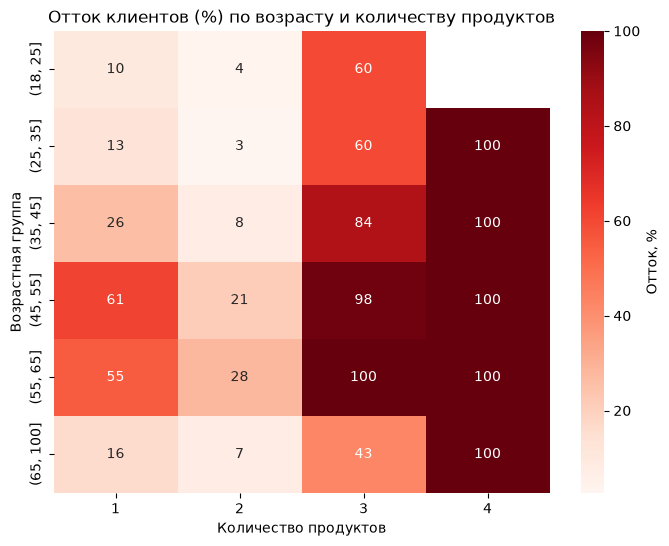

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.groupby(['AgeGroup', 'NumOfProducts'])['Exited'].mean().unstack() * 100

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': 'Отток, %'})
plt.title('Отток клиентов (%) по возрасту и количеству продуктов')
plt.xlabel('Количество продуктов')
plt.ylabel('Возрастная группа')
plt.show()

In [25]:
df['CreditScoreGroup'] = pd.cut(df['CreditScore'], bins=[300, 500, 600, 650, 700, 750, 850])
credit_churn = df.groupby('CreditScoreGroup')['Exited'].agg(['mean', 'count'])
credit_churn

,mean,count
CreditScoreGroup,,
"(300, 500]",0.236392,643
"(500, 600]",0.211721,2423
"(600, 650]",0.209514,1871
"(650, 700]",0.185413,1947
"(700, 750]",0.201581,1518
"(750, 850]",0.196496,1598


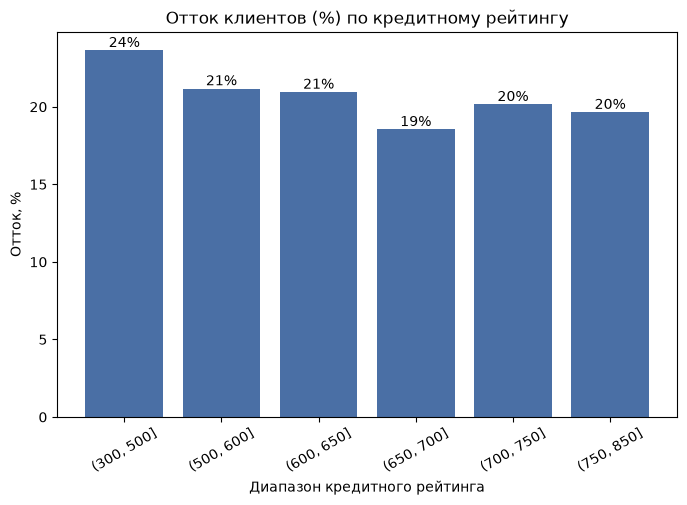

In [26]:
plt.figure(figsize=(8, 5))
bars = plt.bar(credit_churn.index.astype(str), credit_churn['mean'] * 100, color='#4a6fa5')
plt.bar_label(bars, fmt='%.0f%%')
plt.title('Отток клиентов (%) по кредитному рейтингу')
plt.xlabel('Диапазон кредитного рейтинга')
plt.ylabel('Отток, %')
plt.xticks(rotation=30)
plt.show()

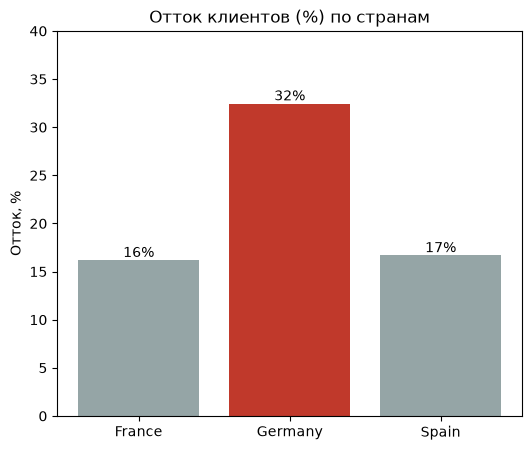

In [27]:
geo_churn = df.groupby('Geography')['Exited'].mean() * 100

colors = ['#c0392b' if country == 'Germany' else '#95a5a6' for country in geo_churn.index]

plt.figure(figsize=(6, 5))
bars = plt.bar(geo_churn.index, geo_churn.values, color=colors)
plt.bar_label(bars, fmt='%.0f%%')
plt.title('Отток клиентов (%) по странам')
plt.ylabel('Отток, %')
plt.ylim(0, 40)
plt.show()

In [28]:
df['BalanceGroup'] = pd.cut(df['Balance'], bins=[-1, 0, 50000, 100000, 150000, 200000, 250000])
balance_churn = df.groupby('BalanceGroup')['Exited'].agg(['mean', 'count'])
balance_churn

,mean,count
BalanceGroup,,
"(-1, 0]",0.138236,3617
"(0, 50000]",0.346667,75
"(50000, 100000]",0.199470,1509
"(100000, 150000]",0.257702,3830
"(150000, 200000]",0.219251,935
"(200000, 250000]",0.545455,33


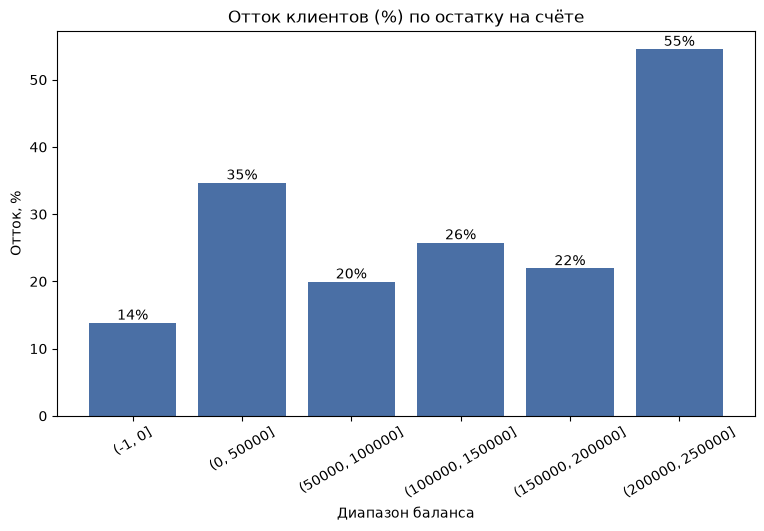

In [29]:
plt.figure(figsize=(9, 5))
bars = plt.bar(balance_churn.index.astype(str), balance_churn['mean'] * 100, color='#4a6fa5')
plt.bar_label(bars, fmt='%.0f%%')
plt.title('Отток клиентов (%) по остатку на счёте')
plt.xlabel('Диапазон баланса')
plt.ylabel('Отток, %')
plt.xticks(rotation=30)
plt.show()

In [30]:
df.groupby('NumOfProducts')['Balance'].agg(['mean', lambda x: (x==0).mean()])

,mean,<lambda_0>
NumOfProducts,,
1,98551.870614,0.178009
2,51879.145813,0.566449
3,75458.328195,0.368421
4,93733.135000,0.233333


In [31]:
df.groupby('Gender')['Exited'].mean() * 100

Gender
Female    25.071539
Male      16.474253
Name: Exited, dtype: float64

In [32]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [33]:
df.groupby(['Gender', 'NumOfProducts'])['Exited'].agg(['mean', 'count'])

mean  count
Gender NumOfProducts                 
Female 1              0.331882   2296
       2              0.101942   2060
       3              0.865772    149
       4              1.000000     38
Male   1              0.232066   2788
       2              0.054941   2530
       3              0.777778    117
       4              1.000000     22

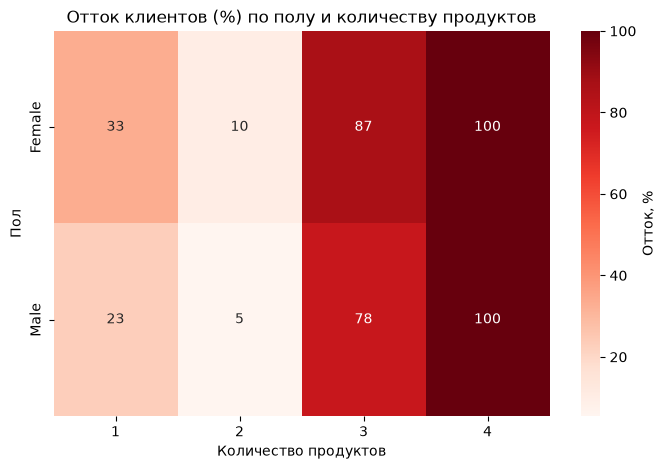

In [34]:
pivot = df.groupby(['Gender', 'NumOfProducts'])['Exited'].mean().unstack() * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': 'Отток, %'})
plt.title('Отток клиентов (%) по полу и количеству продуктов')
plt.xlabel('Количество продуктов')
plt.ylabel('Пол')
plt.show()

In [35]:
df.groupby(['Gender','NumOfProducts']).size()

Gender  NumOfProducts
Female  1                2296
        2                2060
        3                 149
        4                  38
Male    1                2788
        2                2530
        3                 117
        4                  22
dtype: int64

In [36]:
df_to_load = df.drop(columns=['AgeGroup', 'CreditScoreGroup', 'BalanceGroup'])

df_to_load.columns = (
    df_to_load.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df_to_load.columns

Index(['rownumber', 'customerid', 'surname', 'creditscore', 'geography',
       'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited', 'complain',
       'satisfaction_score', 'card_type', 'point_earned'],
      dtype='str')

In [37]:
from sqlalchemy import create_engine

engine = create_engine('postgresql://dara@localhost:5432/bank_churn_to_retention')

df_to_load.to_sql('customers', engine, if_exists='replace', index=False)

1000

In [38]:
df_to_load.shape

(10000, 18)

In [39]:
pd.read_sql('SELECT COUNT(*) FROM customers', engine)

,count
0,10000


In [40]:
import numpy as np

bins = [-0.01, 0, 10000, 25000, 50000, 100000, 150000, df['Balance'].max()]
labels = ['0 (ровно)', '0-10k', '10k-25k', '25k-50k', '50k-100k', '100k-150k', '150k+']

df['balance_fine'] = pd.cut(df['Balance'], bins=bins, labels=labels)

df.groupby('balance_fine', observed=True)['Exited'].agg(['mean', 'count'])

,mean,count
balance_fine,,
0 (ровно),0.138236,3617
0-10k,1.000000,1
10k-25k,0.600000,5
25k-50k,0.318841,69
50k-100k,0.199470,1509
100k-150k,0.257702,3830
150k+,0.231166,969
